In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Aditya Deshmukh\Datasets\walmart_data.csv")
df = data.copy()
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [3]:
df.tail(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category            550068 non-null  int64
 9   Purchase                    550068 non-null  int64
dtypes: int64(5), str(5)
memory usage: 42.0 MB


In [5]:
df.shape

(550068, 10)

In [6]:
for i in df.columns:
    print(f"{i} : {df[i].nunique()} ")

User_ID : 5891 
Product_ID : 3631 
Gender : 2 
Age : 7 
Occupation : 21 
City_Category : 3 
Stay_In_Current_City_Years : 5 
Marital_Status : 2 
Product_Category : 20 
Purchase : 18105 


In [7]:
df.isna().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

there are no missing values in the data

In [8]:
cat_cols = [
    'Gender',
    'Age',
    'Occupation',
    'City_Category',
    'Stay_In_Current_City_Years',
    'Marital_Status',
    'Product_Category'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  str     
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  category
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  int64   
dtypes: category(7), int64(2), str(1)
memory usage: 16.3 MB


In [10]:
cat_cols = list(df.select_dtypes(include=["str","category"]).columns)
num_cols = list(df.select_dtypes(include=["int64","float64"]).columns)
print(f"categorical : {cat_cols}")
print(f"numerical : {num_cols}")

categorical : ['Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']
numerical : ['User_ID', 'Purchase']


In [11]:
df['Occupation'].unique()

[10, 16, 15, 7, 20, ..., 18, 5, 14, 13, 6]
Length: 21
Categories (21, int64): [0, 1, 2, 3, ..., 17, 18, 19, 20]

In [12]:
ratio = df['User_ID'].nunique() / len(df)
ratio

0.010709584996764037

<function matplotlib.pyplot.show(close=None, block=None)>

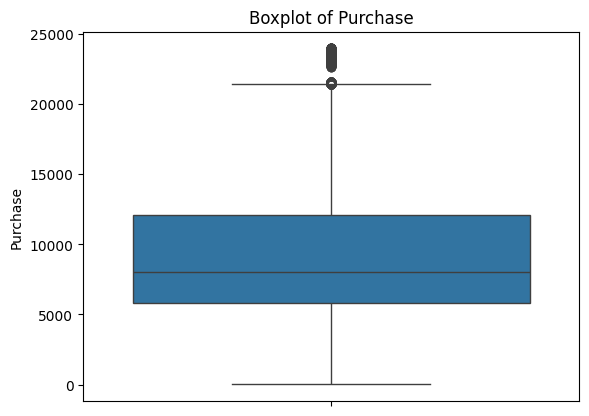

In [13]:
plt.figure()
sns.boxplot(y=df['Purchase'])
plt.title('Boxplot of Purchase')
plt.show

In [14]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Purchase'] < lower) | (df['Purchase'] > upper)]

print(f"Purchase: {len(outliers)} outliers")

Purchase: 2677 outliers


In [15]:
df['Purchase'] = np.clip(df['Purchase'],df['Purchase'].quantile(0.05) , df['Purchase'].quantile(0.95))

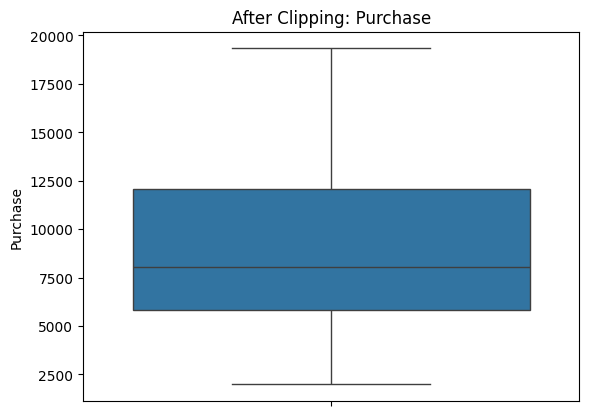

In [16]:
plt.figure()
sns.boxplot(y=df['Purchase'])
plt.title('After Clipping: Purchase')
plt.show()

In [17]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Purchase'] < lower) | (df['Purchase'] > upper)]

print(f"Purchase: {len(outliers)} outliers")

Purchase: 0 outliers


### Univariate-Bivariate Analysis

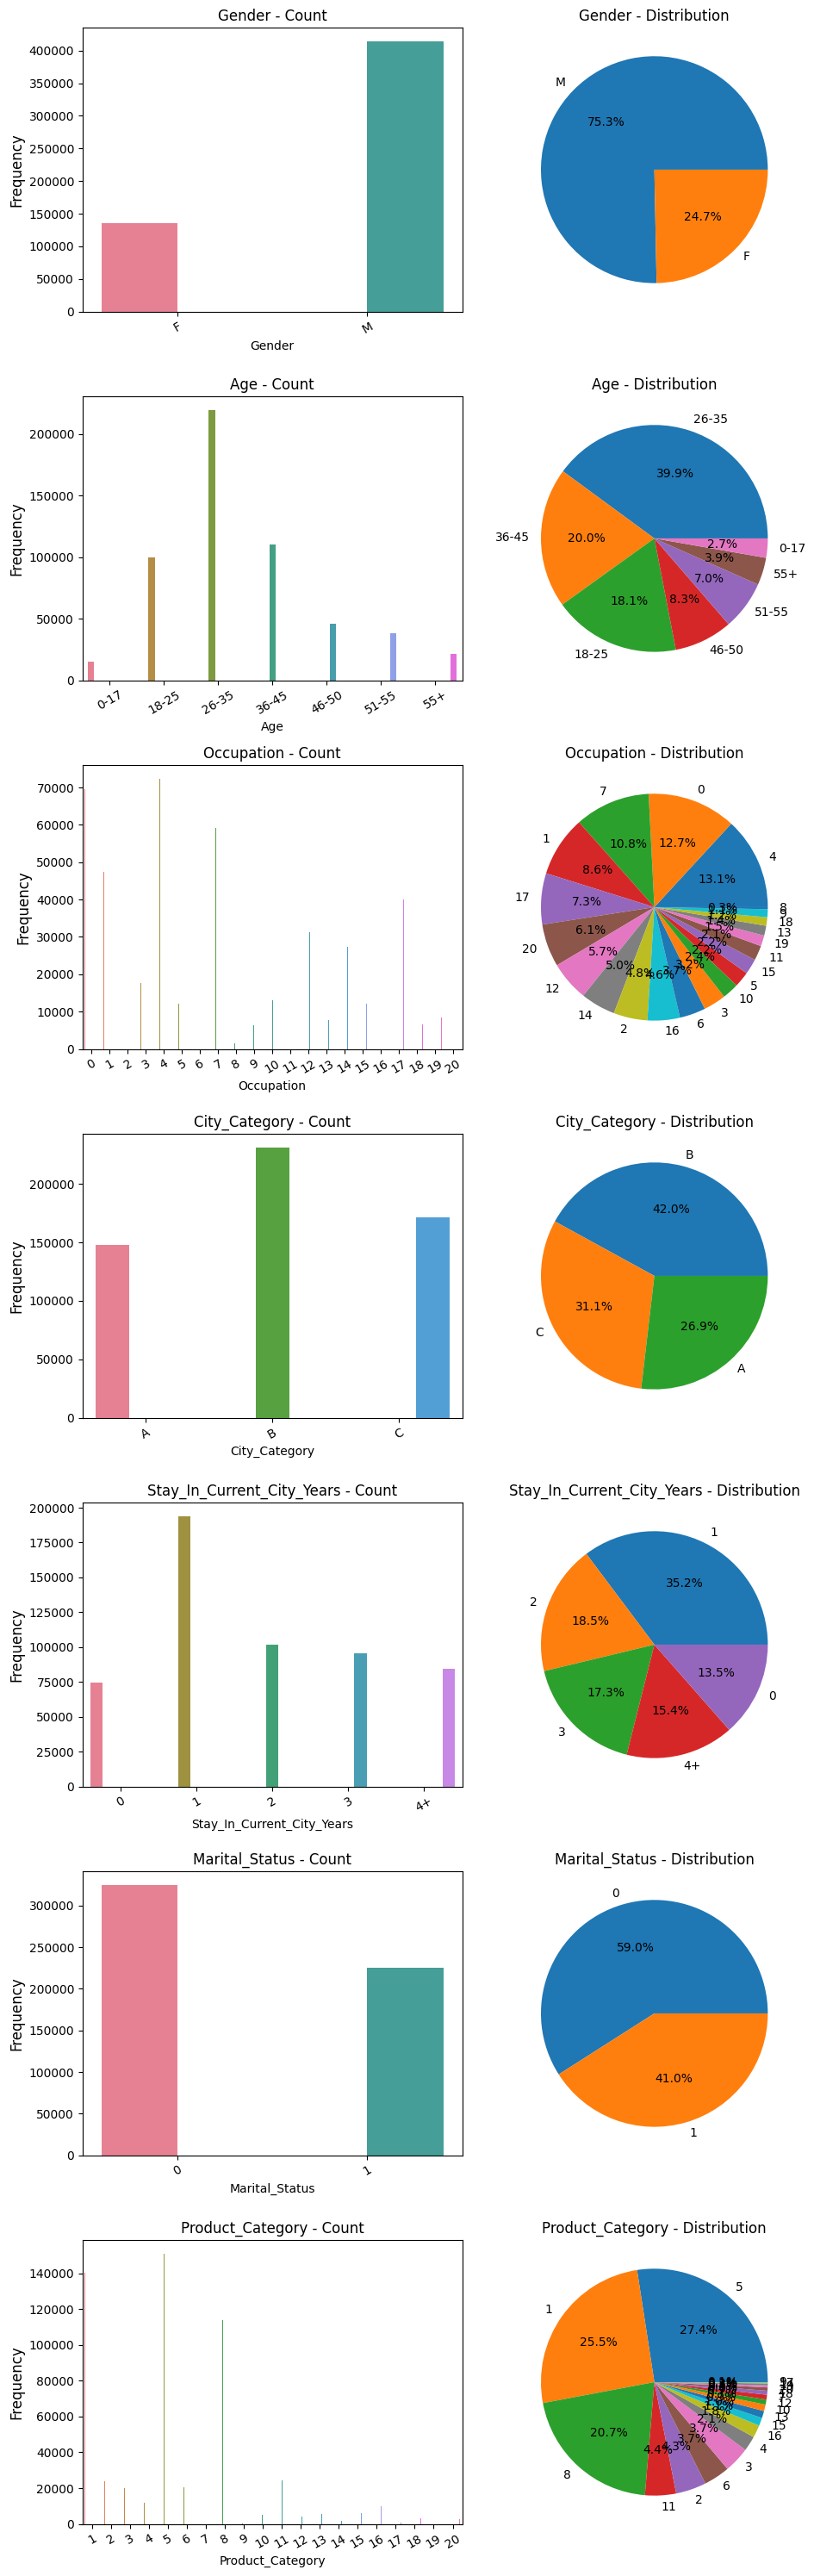

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid (7 rows, 2 columns)
fig, axes = plt.subplots(7, 2, figsize=(10, 30))

columns = [
     'Gender',
     'Age',
    'Occupation', 
    'City_Category',
    'Stay_In_Current_City_Years', 
    'Marital_Status', 
    'Product_Category'

]

for i, col in enumerate(columns):
    
    # BAR PLOT
    sns.countplot(
        x=col,
        data=df,
        ax=axes[i][0],
        hue = col,
        palette="husl",
        legend = False
    )
    axes[i][0].set_title(f"{col} - Count", fontsize=12)
    axes[i][0].set_ylabel("Frequency", fontsize=12)
    axes[i][0].tick_params(axis='x', rotation=30)
    
    # PIE CHART
    df[col].value_counts().plot.pie(
        autopct="%.1f%%",
        ax=axes[i][1],
        textprops={"fontsize": 10}
    )
    axes[i][1].set_title(f"{col} - Distribution", fontsize=12)
    axes[i][1].set_ylabel("")

plt.tight_layout()
plt.show()

# Key Insights

1. Product categories **5, 1, and 8** are the most frequently purchased categories, with Category 5 alone contributing approximately **27.4%** of total purchases.

2. Approximately **75.3%** of customers purchasing products are male, indicating significantly higher participation from male customers compared to females.

3. Around **59%** of customers are unmarried, while **41%** are married, showing higher shopping frequency among unmarried customers.

4. Customers aged **26–35 years** form the largest customer segment, contributing nearly **40%** of the total customer base.

5. **City Category B** contributes the highest customer share at approximately **42%**, followed by Categories C and A.

6. Customers who have stayed in the current city for **1 year** account for the highest proportion of shoppers (**35.2%**), suggesting stronger activity among relatively newer residents.

7. Occupation categories **0, 4, and 7** represent some of the most active customer groups in the dataset.

8. Product categories **1, 6, 7, 10, 14, and 16** show comparatively higher purchase amounts based on median purchase distribution.

9. Product categories such as **4, 11, 12, 13, 18, 19, and 20** have relatively lower purchase values compared to other categories.

10. The dataset indicates that young to middle-aged adults, particularly males from City Category B, form the dominant consumer segment.

### Bivariate Analysis

#####   Age vs Purchase

C:\Users\Aditya Deshmukh\AppData\Local\Temp\ipykernel_6020\1979253957.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Aditya Deshmukh\AppData\Local\Temp\ipykernel_6020\1979253957.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


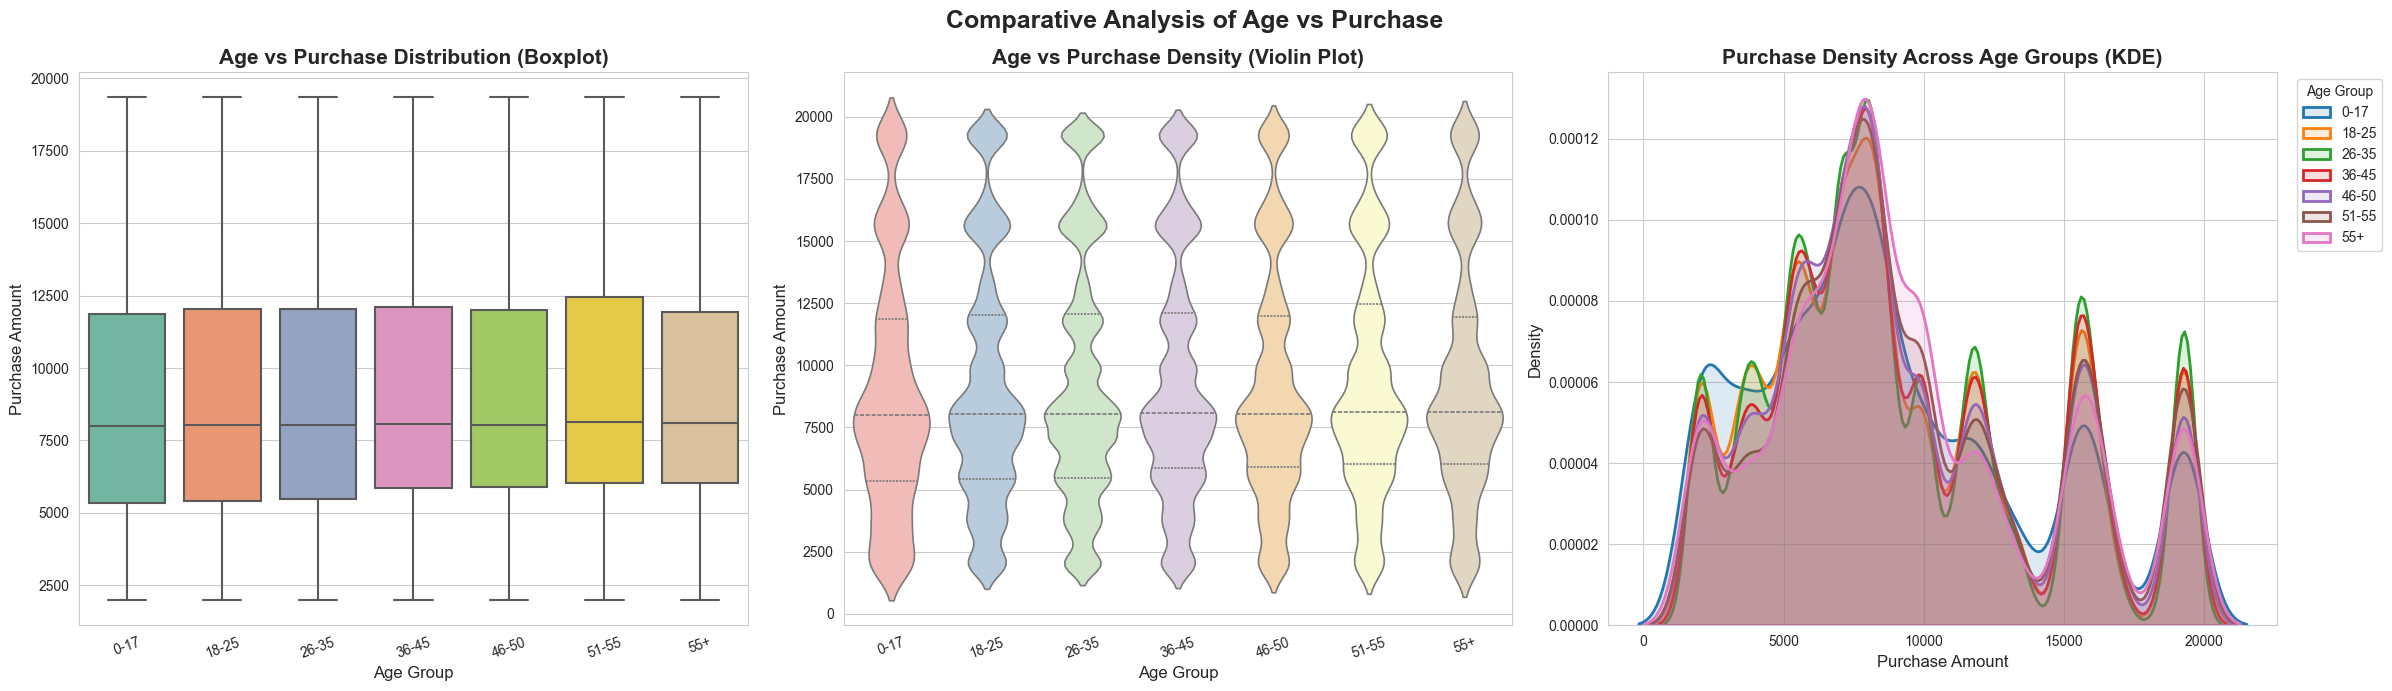

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (24, 7)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Boxplot
sns.boxplot(
    x='Age',
    y='Purchase',
    data=df,
    palette='Set2',
    linewidth=1.5,
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title(
    'Age vs Purchase Distribution (Boxplot)',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Purchase Amount', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)

# Violin Plot
sns.violinplot(
    x='Age',
    y='Purchase',
    data=df,
    palette='Pastel1',
    inner='quartile',
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title(
    'Age vs Purchase Density (Violin Plot)',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Purchase Amount', fontsize=12)
axes[1].tick_params(axis='x', rotation=20)

# Kde plot
age_groups = sorted(df['Age'].unique())

for age_group in age_groups:
    sns.kdeplot(
        data=df[df['Age'] == age_group],
        x='Purchase',
        fill=True,
        alpha=0.15,
        linewidth=2,
        label=age_group,
        ax=axes[2]
    )

axes[2].set_title(
    'Purchase Density Across Age Groups (KDE)',
    fontsize=15,
    fontweight='bold'
)

axes[2].set_xlabel('Purchase Amount', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)

axes[2].legend(
    title='Age Group',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


plt.suptitle(
    'Comparative Analysis of Age vs Purchase',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [20]:
groups_age = [
    df[df['Age'] == age]['Purchase']
    for age in df['Age'].unique()
]


In [21]:
# we will use anova to check relation of age as categorical vs purchase

# we check if age fullfills the conditions for Anova

# 1. Check if the Data is Normally Distributed

# H0: Normally Distributed
# Ha: Not Normally Distributed

In [22]:
from scipy.stats import shapiro

stat, p_value = shapiro(df['Purchase'])

print("Shapiro Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")


Shapiro Statistic: 0.9364252285461521
p-value: 1.4953071428930613e-131
Data is NOT normally distributed


C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 550068.
  res = hypotest_fun_out(*samples, **kwds)


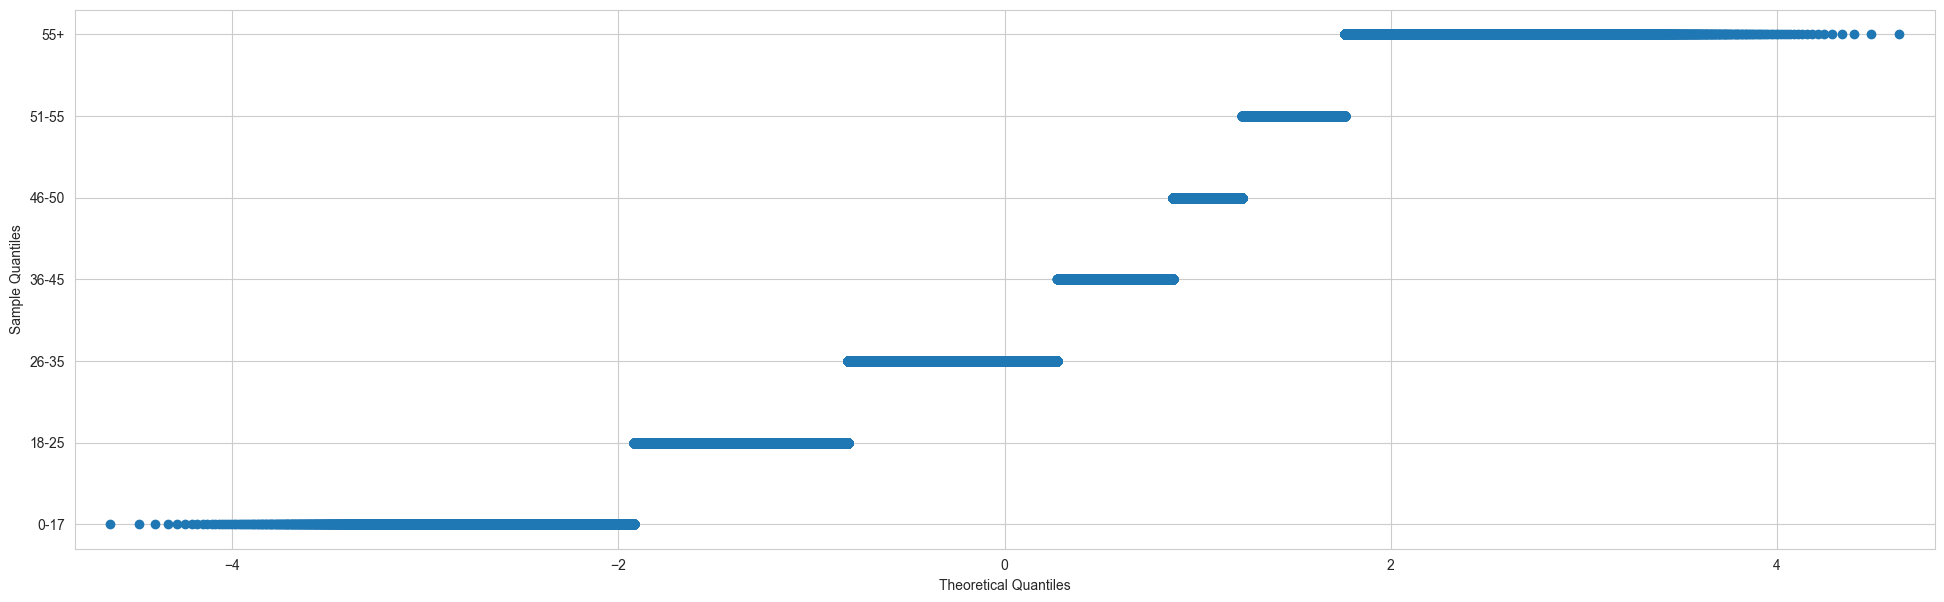

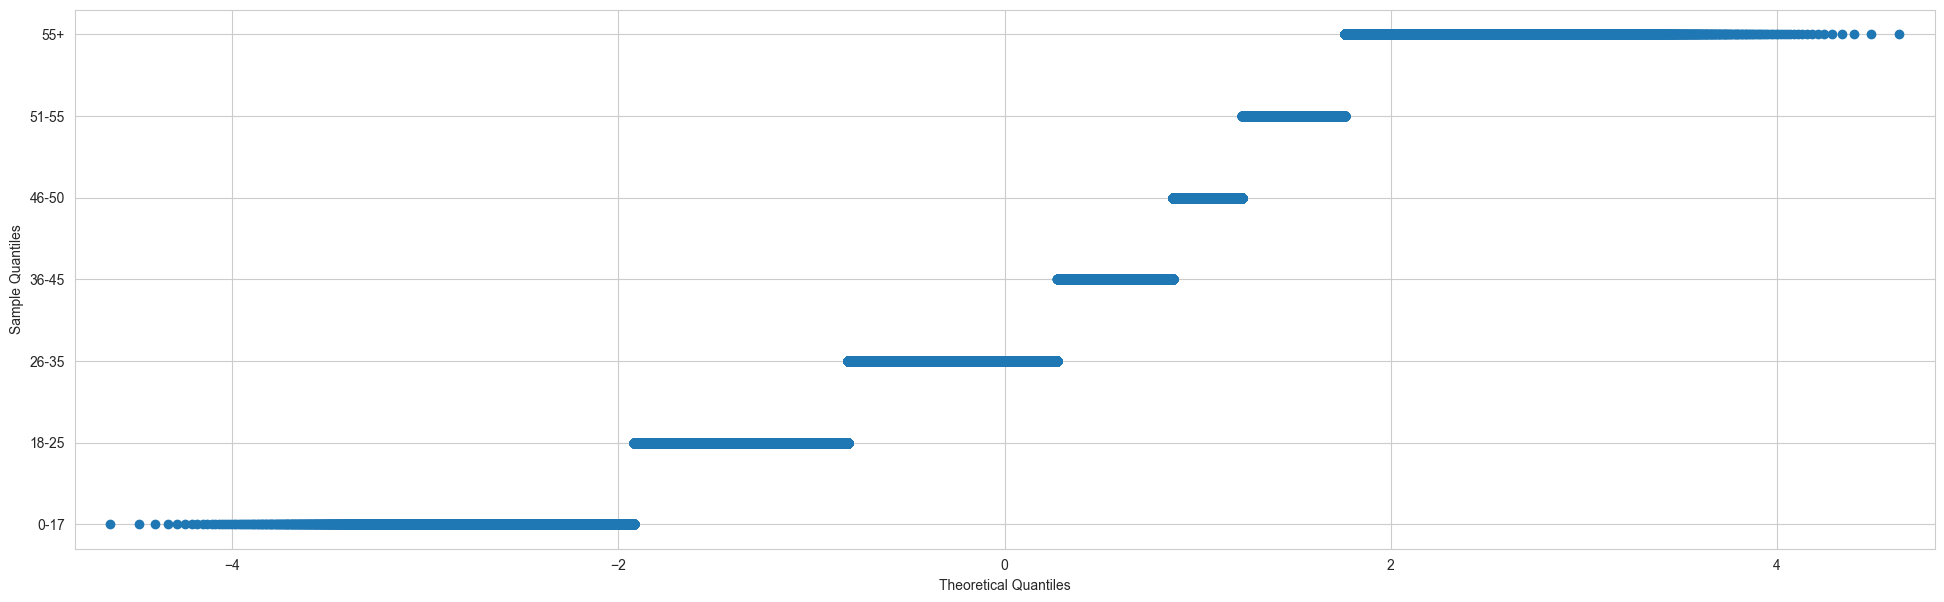

In [23]:
from statsmodels.graphics.gofplots import qqplot

qqplot(data= df["Age"])

In [24]:
from scipy.stats import levene,kruskal

In [25]:
stat, p_value = levene(*groups_age)

print("Levene Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Variances are NOT equal (assumption violated) , Reject H0")
else:
    print("Variances are equal (assumption satisfied) , Fail to Reject H0 ")

Levene Statistic: 15.88253276087288
p-value: 2.408983118206475e-18
Variances are NOT equal (assumption violated) , Reject H0


In [26]:
# Krushkal- Wallis Test as Normality does not hold

# H0: Purchase distributions differ across age groups
# Ha: No significant difference in purchase distributions across age groups

In [27]:
from scipy.stats import kruskal

stat, p_value = kruskal(*groups_age)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Purchase distributions differ across age groups")
else:
    print("Fail to reject H0 → No significant difference in purchase distributions across age groups")

Kruskal Statistic: 316.4269448321753
p-value: 2.4643859961952855e-65
Reject H0 → Purchase distributions differ across age groups


Although the statistical test indicates significant differences,
visualizations show substantial overlap between age groups,
suggesting that the practical impact of age on purchase amount may be limited.

- Customers belonging to the **26–35** age group form the largest customer segment in the dataset.
- Visual analysis using boxplots, violin plots, and KDE plots shows that purchase distributions across age groups are highly overlapping and relatively similar.
- Although the Kruskal-Wallis test indicates statistically significant differences in purchase distributions between age groups, the actual variation in purchase behavior appears relatively small in practical terms.
- Median purchase values and overall purchase spread remain fairly consistent across most age categories.
- This suggests that while age has a statistically detectable relationship with purchase amount, it may not be one of the strongest factors influencing customer spending behavior.
- Other variables such as product category, occupation, or city category may have a comparatively greater impact on purchase amount.

In [28]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='str')

##### Gender vs Purchase

In [29]:
bins = [0, 5000, 10000, 15000, 25000]

labels = [
    'Low Spend',
    'Medium Spend',
    'High Spend',
    'Premium Spend'
]

df['Purchase_Bins'] = pd.cut(
    df['Purchase'],
    bins=bins,
    labels=labels
)

In [30]:
grp = df.groupby(['Purchase_Bins','Gender']).size().reset_index(name='counts')
grp

,Purchase_Bins,Gender,counts
0,Low Spend,F,24239
1,Low Spend,M,70684
2,Medium Spend,F,72629
3,Medium Spend,M,193066
4,High Spend,F,17512
5,High Spend,M,61415
6,Premium Spend,F,21429
7,Premium Spend,M,89094


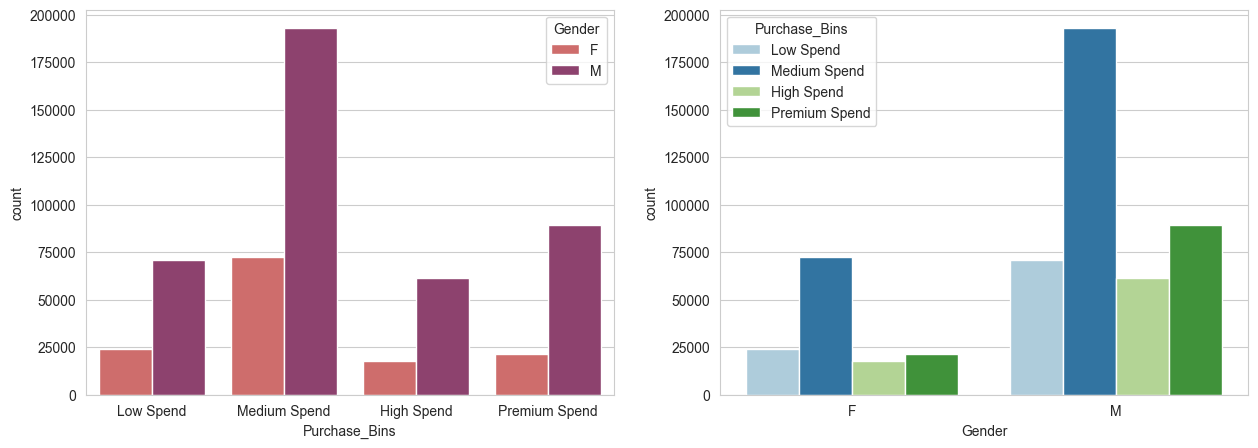

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Purchase_Bins', hue='Gender', palette="flare", ax=axes[0]) 
sns.countplot(data = df, x='Gender', hue='Purchase_Bins', palette="Paired", ax=axes[1])

plt.show()

- The data itself is male dominaated so we create a normalised table to actually check the percentages as raw values will always show 

In [32]:



normalized_table_gender = pd.crosstab(
    df['Gender'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

normalized_table_gender

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
Gender,,,,
F,17.847860,53.478783,12.894580,15.778778
M,17.062755,46.605143,14.825266,21.506835


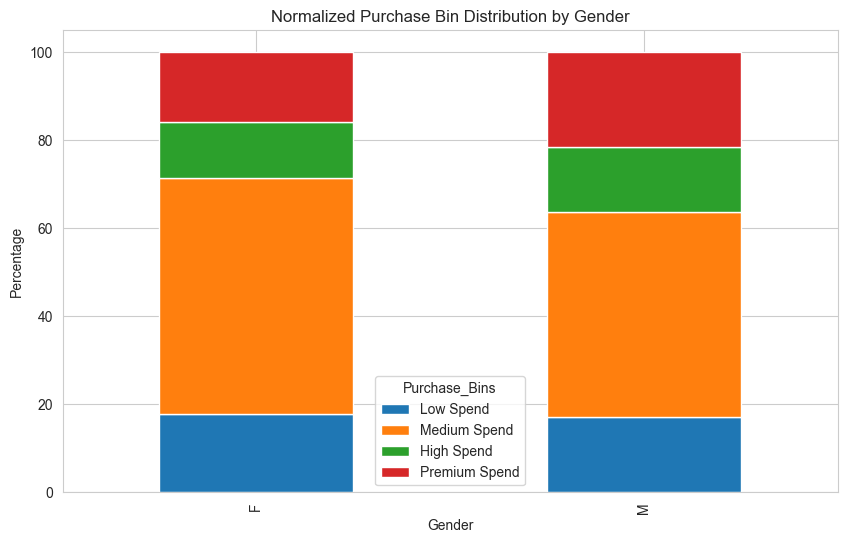

In [33]:
normalized_table_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Normalized Purchase Bin Distribution by Gender')
plt.ylabel('Percentage')
plt.legend(title='Purchase_Bins')
plt.show()

In [34]:
from scipy.stats import chi2_contingency


G_P_matrix = pd.crosstab( df['Gender'],
    df['Purchase_Bins'])


test_statistic, p_value, dof, expected_values = chi2_contingency(G_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e.Gender and Purchase_Bins are dependent .")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. Gender and Purchase_Bins are independent")


Test statistic: 2972.853432591687
p-value: 0.0
dof 3
expected_values [[ 23436.00737909  65598.74825476  19486.67608914  27287.56827701]
 [ 71486.99262091 200096.25174524  59440.32391086  83235.43172299]]
Reject H0 (Null Hypothesis),i.e.Gender and Purchase_Bins are dependent .


###### Gender vs Purchase Bin Insights

- Female customers are more concentrated in the **Medium Spend** category, with approximately **53.48%** of female customers falling into this segment.

- Male customers have a higher proportion in the **Premium Spend** category (**21.51%**) compared to female customers (**15.78%**).

- Male customers also show a slightly higher representation in the **High Spend** category (**14.83%**) than female customers (**12.89%**).

- The proportion of customers in the **Low Spend** category is relatively similar across genders, with females at **17.85%** and males at **17.06%**.

- Overall, male customers appear more likely to fall into higher spending segments compared to female customers.

- Female customers are more concentrated in moderate spending ranges, whereas male customers show greater representation among high-value and premium purchasers.

In [35]:
# Checking CLT and CI

In [36]:
male_purchase = df[df['Gender'] == 'M']['Purchase']
female_purchase = df[df['Gender'] == 'F']['Purchase']

In [37]:
sample_means_male = []

for i in range(1000):
    sample = male_purchase.sample(500, replace=True)
    sample_means_male.append(sample.mean())
    

<Axes: ylabel='Count'>

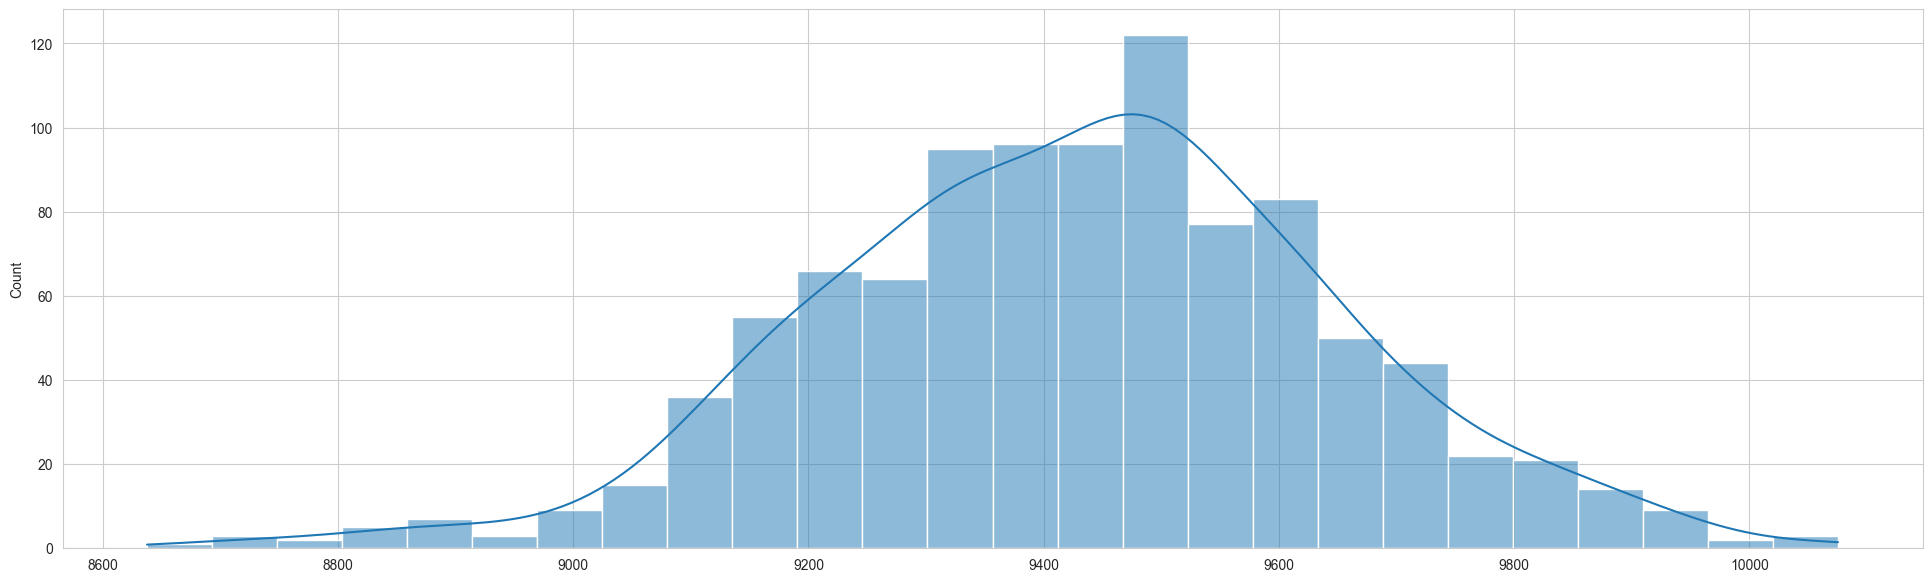

In [38]:
sns.histplot(x=sample_means_male, kde=True)

In [39]:
import scipy.stats as stats

mean = male_purchase.mean()
std = male_purchase.std()
n = len(male_purchase)

confidence = 0.95

male_ci = stats.norm.interval(
    confidence,
    loc=mean,
    scale=std / np.sqrt(n) # Standard Error
)

male_ci

(np.float64(9412.240611016148), np.float64(9442.241382133065))

In [40]:
sample_means_female = []

for i in range(1000):
    sample = female_purchase.sample(500,replace=True)
    sample_means_female.append(sample)


<Axes: ylabel='Count'>

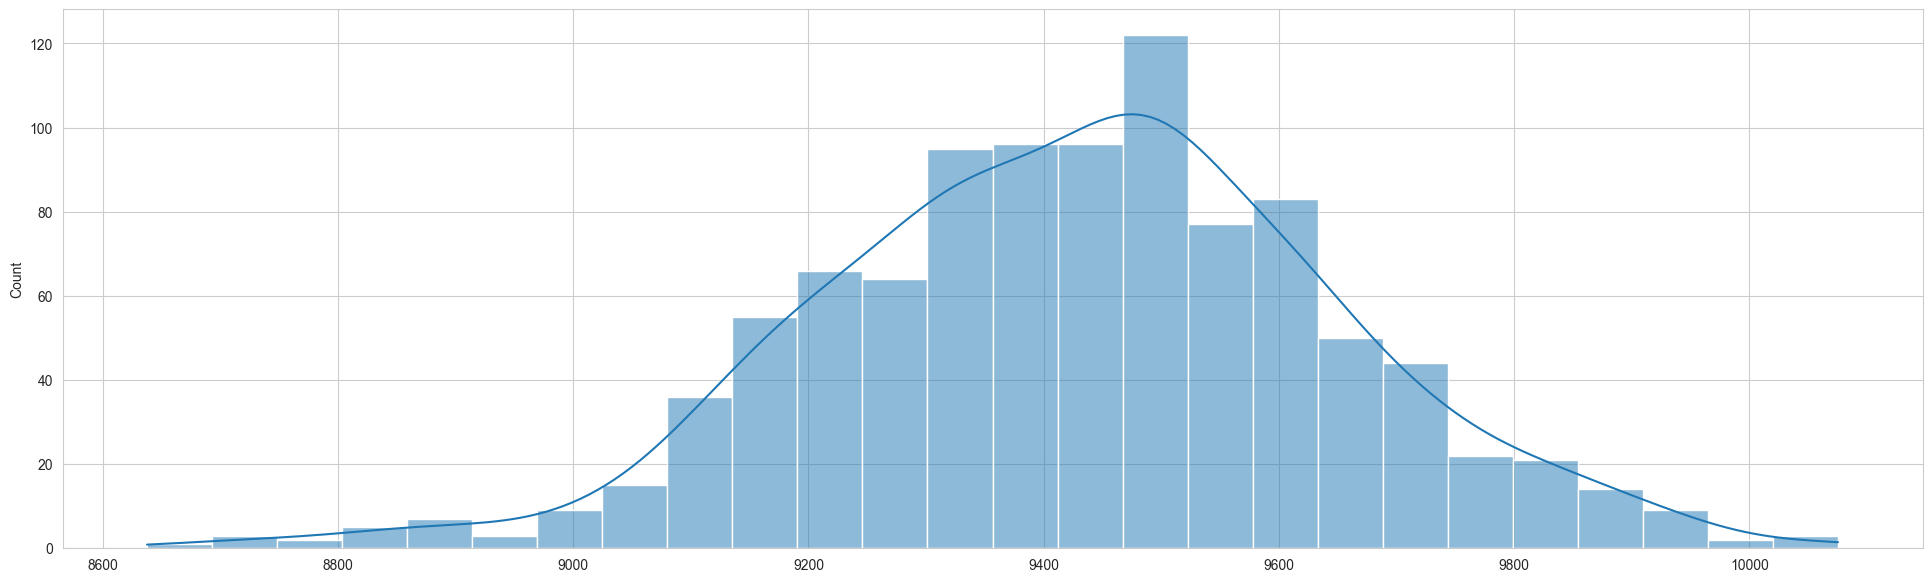

In [41]:
sns.histplot(x=sample_means_male,kde=True)

In [42]:
mean_f = female_purchase.mean()
std_f = female_purchase.std()

n = len(female_purchase)

confidence = 0.95
    
female_ci = stats.norm.interval(
    confidence,
    loc=mean_f,
    scale=std_f / np.sqrt(n)
)

female_ci

(np.float64(8712.091504525708), np.float64(8760.989027692334))

###### Confidence Interval Insights

- The 95% confidence interval for average male purchase amount lies between approximately **9412 and 9442**.
- The 95% confidence interval for average female purchase amount lies between approximately **8712 and 8761**.
- Since the confidence intervals do not overlap, male customers appear to have significantly higher average purchase amounts compared to female customers.
- The intervals are relatively narrow, indicating stable estimates due to the large sample size.

##### Marital_status vs Purchase

In [43]:
df.groupby(['Purchase_Bins','Marital_Status']).size().reset_index(name='counts')

,Purchase_Bins,Marital_Status,counts
0,Low Spend,0,56459
1,Low Spend,1,38464
2,Medium Spend,0,156046
3,Medium Spend,1,109649
4,High Spend,0,46596
5,High Spend,1,32331
6,Premium Spend,0,65630
7,Premium Spend,1,44893


<Axes: xlabel='Marital_Status', ylabel='count'>

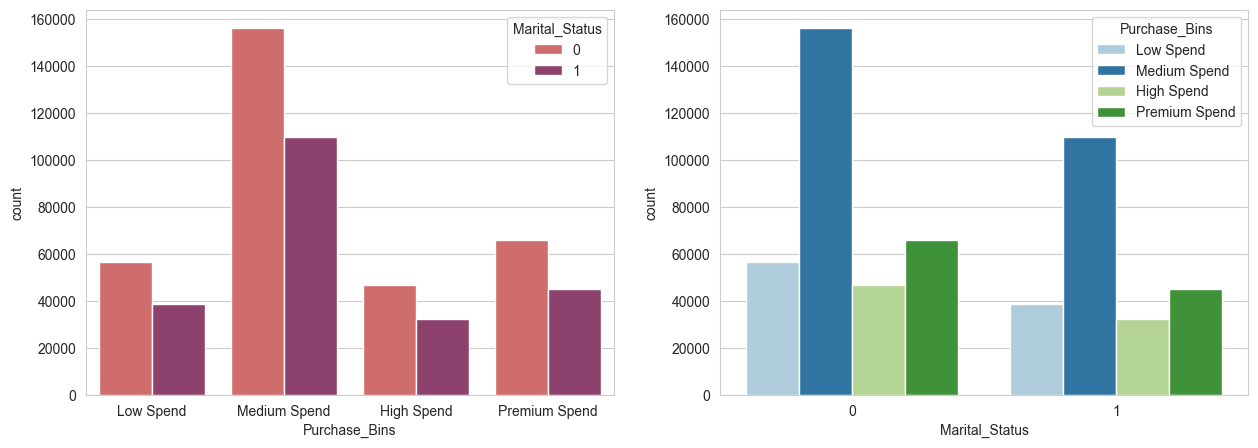

In [44]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'Marital_Status', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Marital_Status', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



- Purchase segment distributions across marital status categories appear relatively similar.
- Both married and unmarried customers are concentrated primarily in the Medium Spend category.
- No strong separation in spending behavior is visually observed between the two marital status groups.
- This suggests that marital status may not be a major factor influencing customer purchase behavior.

In [45]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

##### occupation vs Purchase

<Axes: xlabel='Marital_Status', ylabel='count'>

C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


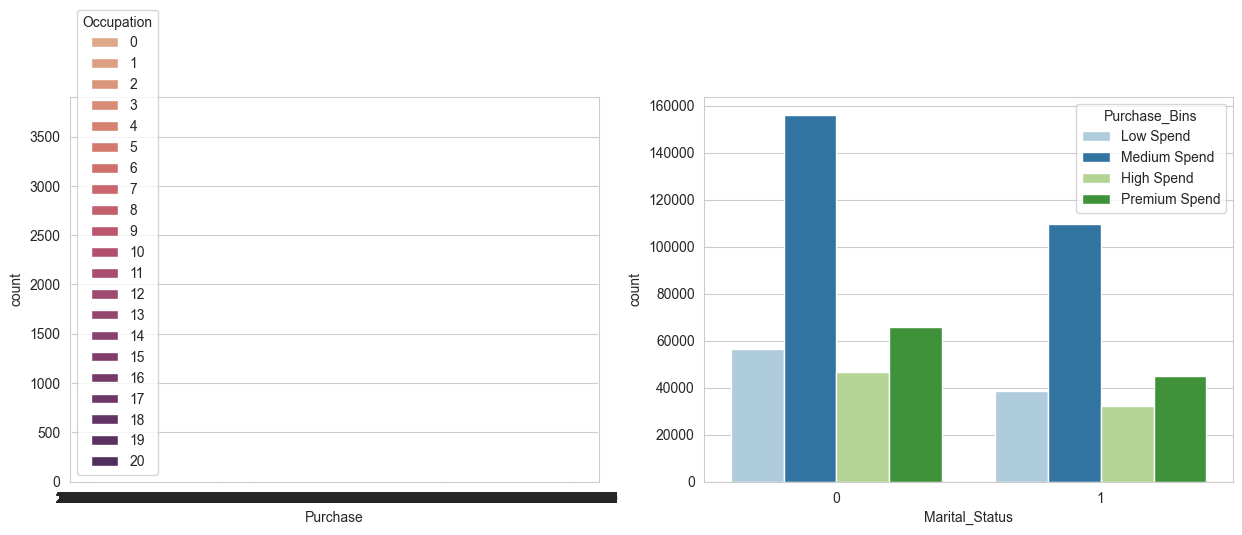

In [46]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase', hue= 'Occupation', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Marital_Status', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])


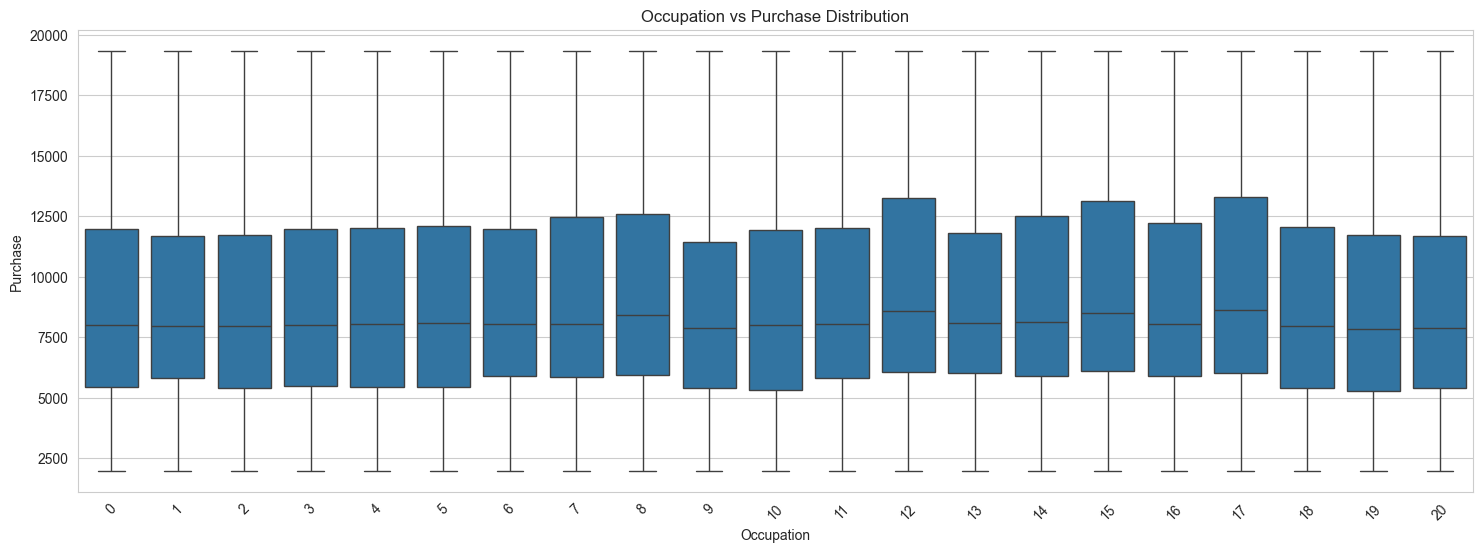

In [47]:
plt.figure(figsize=(18,6))

sns.boxplot(
    x='Occupation',
    y='Purchase',
    data=df,
    showfliers=False
)

plt.title('Occupation vs Purchase Distribution')
plt.xticks(rotation=45)
plt.show()

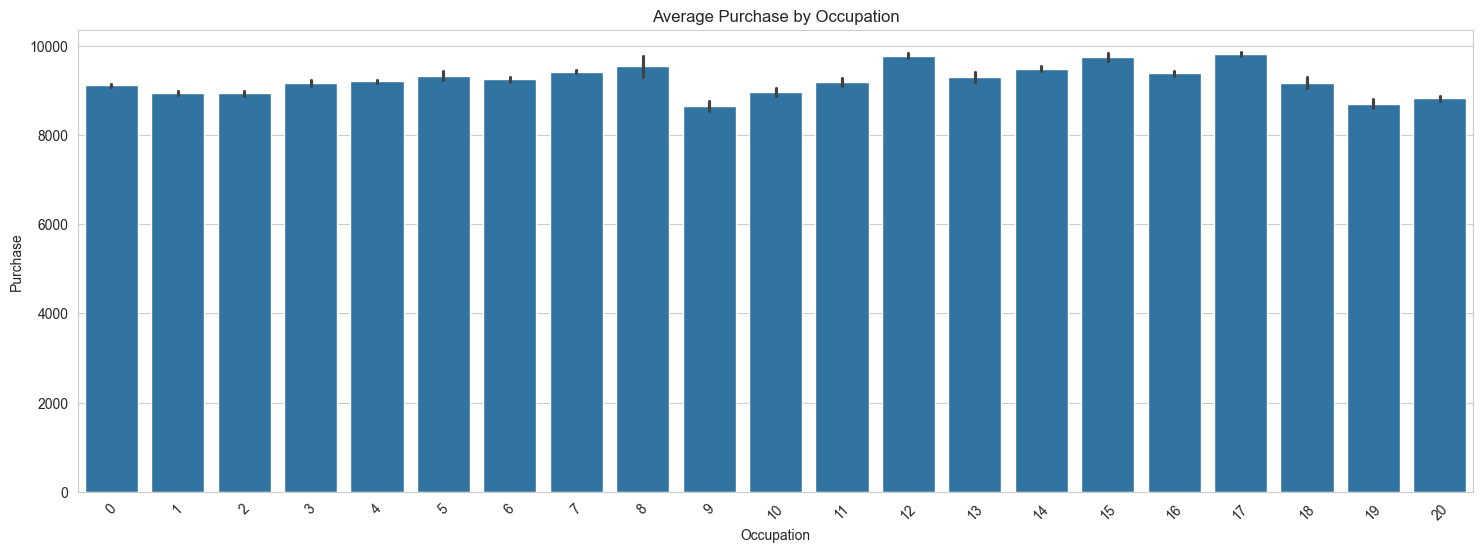

In [48]:
plt.figure(figsize=(18,6))

sns.barplot(
    x='Occupation',
    y='Purchase',
    data=df
)

plt.title('Average Purchase by Occupation')
plt.xticks(rotation=45)
plt.show()

In [49]:
occupation_mean = df.groupby('Occupation')['Purchase'].mean()

occupation_mean.sort_values(ascending=False)

Occupation
17    9816.474340
12    9782.292152
15    9757.346650
8     9537.546572
14    9488.400161
7     9420.474490
16    9386.824642
5     9328.595631
13    9300.149198
6     9246.361238
4     9208.712203
11    9197.213706
3     9170.350368
18    9169.565690
0     9118.530544
10    8972.975251
1     8948.985873
2     8939.499511
20    8821.253143
19    8705.822598
9     8655.518677
Name: Purchase, dtype: float64

In [50]:

groups_occ = [df[df['Occupation'] == occ ]['Purchase'] for occ in df['Occupation'].unique()]


stat, p_value = kruskal(*groups_occ)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Purchase distributions differ across occupations")
else:
    print("Fail to reject H0 → No significant difference in purchase distributions across occupations")

Kruskal Statistic: 1947.887869459302
p-value: 0.0
Reject H0 → Purchase distributions differ across occupations



- The Kruskal-Wallis test indicates statistically significant differences in purchase distributions across occupation groups.
- However, boxplot analysis shows substantial overlap between occupation-wise purchase distributions.
- Although certain occupations exhibit relatively higher average purchase amounts, the practical differences appear moderate rather than extreme.
- This suggests that occupation contributes to customer purchasing behavior, but may not independently act as a dominant predictor of purchase amount.

In [51]:
df.columns


Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

<Axes: xlabel='City_Category', ylabel='count'>

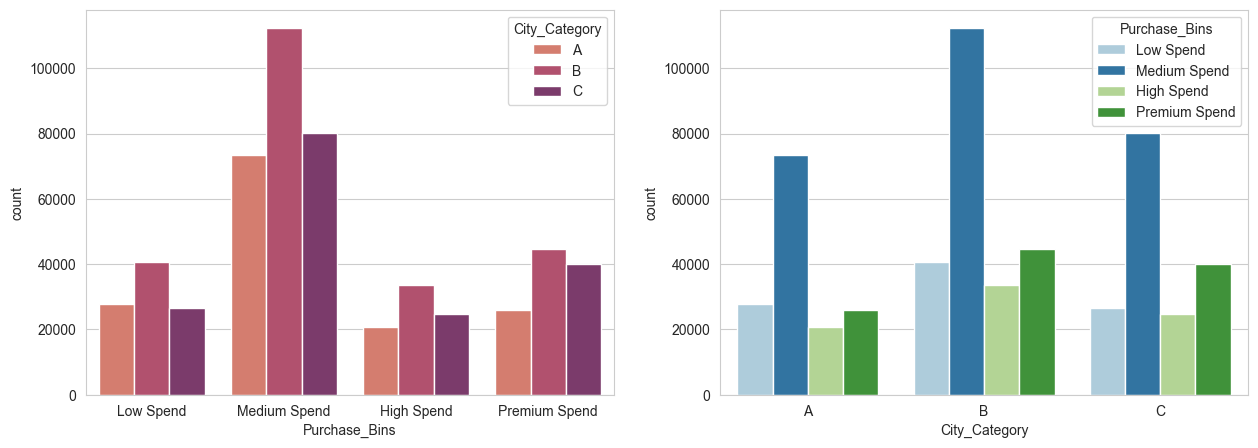

In [52]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'City_Category', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'City_Category', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



In [53]:
city_norm = pd.crosstab(
    df['City_Category'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

city_norm

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
City_Category,,,,
A,18.835635,49.608719,14.008259,17.547387
B,17.582071,48.612944,14.484390,19.320595
C,15.454360,46.755075,14.458887,23.331678




- Customers across all city categories are predominantly concentrated in the Medium Spend segment.
- City Category C exhibits the highest proportion of Premium Spend customers (~23.33%), indicating a relatively stronger concentration of high-value customers.
- City Category A contains the highest proportion of Low Spend customers (~18.84%), suggesting comparatively lower spending behavior.
- City Categories B and C show relatively stronger representation in higher spending segments compared to City Category A.
- Overall, city category appears to have a moderate influence on customer spending behavior and may provide useful information for customer targeting and segmentation strategies.

##### Stay_In_Current_City_Years vs Purchhase

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

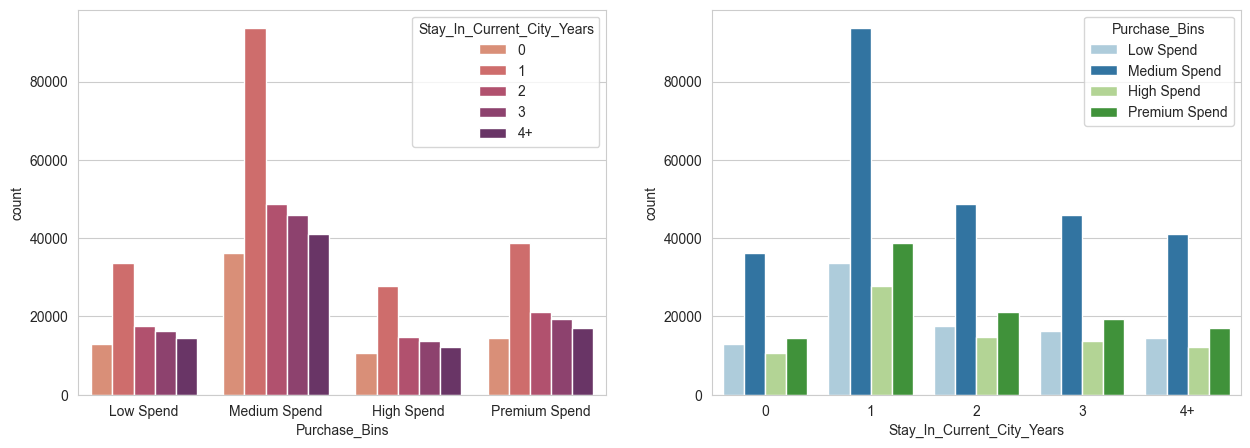

In [54]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'Stay_In_Current_City_Years', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Stay_In_Current_City_Years', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



In [55]:
city_norm = pd.crosstab(
    df['Stay_In_Current_City_Years'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

city_norm

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
Stay_In_Current_City_Years,,,,
0,17.526009,48.715019,14.378075,19.380897
1,17.359832,48.339963,14.306499,19.993706
2,17.125238,47.852472,14.400322,20.621968
3,17.118119,48.222700,14.363226,20.295954
4+,17.097467,48.483346,14.340344,20.078842


- Purchase segment distributions remain highly consistent across all customer groups based on years spent in the current city.
- Overall, the number of years a customer has stayed in the current city does not appear to strongly influence customer spending behavior.

##### Multivariate-Analysis

###### Gender x Product Category vs Purchase

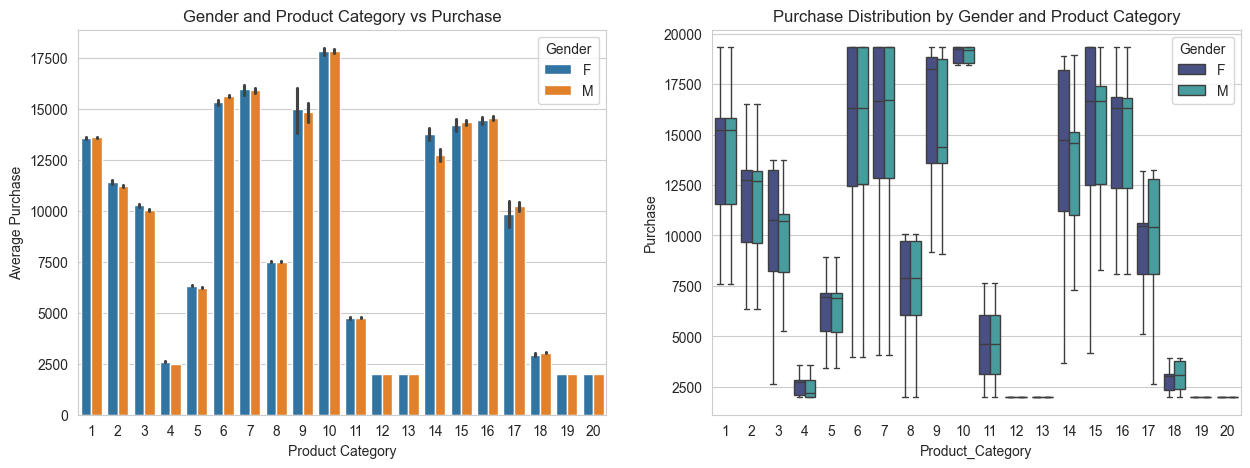

In [59]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Barplot

sns.barplot(
    x='Product_Category',
    y='Purchase',
    hue='Gender',
    data=df,
    ax= axes[0]
)

axes[0].set_title('Gender and Product Category vs Purchase')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Purchase')

# Boxplot

sns.boxplot(
    x='Product_Category',
    y='Purchase',
    hue='Gender',
    palette = 'mako',
    data=df,
    showfliers=False,
    ax = axes[1]
)

axes[1].set_title('Purchase Distribution by Gender and Product Category')


plt.show()

- Product category appears to have a stronger influence on purchase amount compared to gender alone.
- Purchase distributions vary significantly across product categories, while male and female purchase patterns within many categories remain relatively similar.
- Certain product categories exhibit noticeable gender-based differences in average purchase amount, suggesting possible differences in product preferences across genders.
- Product categories `9`, `10`, `15`, and `16` consistently show the highest purchase amounts across both male and female customers, indicating the presence of high-value product segments.
- Categories such as `12`, `13`, `19`, and `20` display minimal variation in purchase values, suggesting relatively fixed or standardized pricing behavior.
- Overall, customer spending behavior appears to be driven more strongly by product category than by gender individually.

###### Gender × City_Category vs Purchase

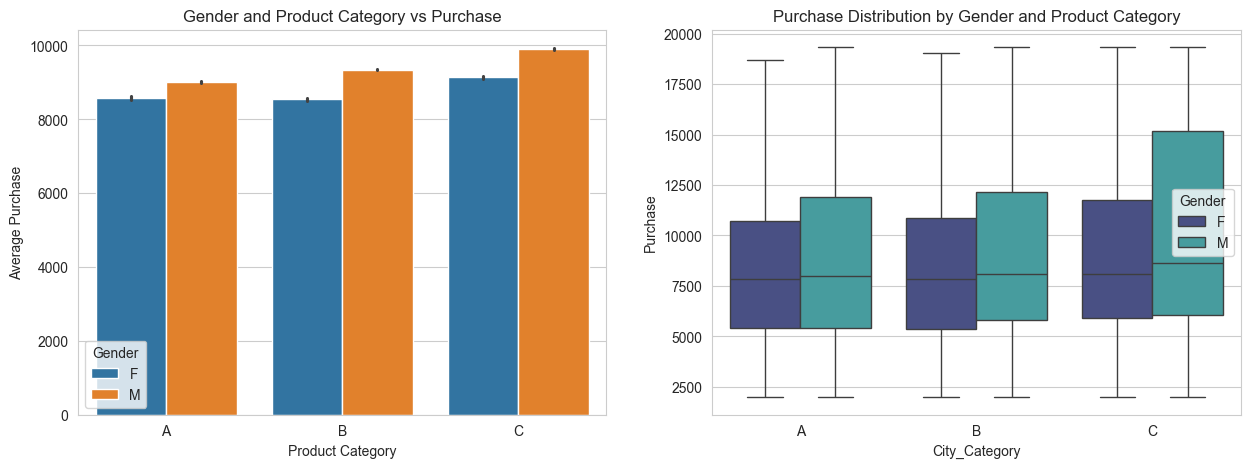

In [60]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Barplot

sns.barplot(
    x='City_Category',
    y='Purchase',
    hue='Gender',
    data=df,
    ax= axes[0]
)

axes[0].set_title('Gender and Product Category vs Purchase')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Purchase')

# Boxplot

sns.boxplot(
    x='City_Category',
    y='Purchase',
    hue='Gender',
    palette = 'mako',
    data=df,
    showfliers=False,
    ax = axes[1]
)

axes[1].set_title('Purchase Distribution by Gender and Product Category')


plt.show()

In [ ]:

corr = df[['Age', 'Income', 'Usage', 'Fitness', 'Miles']].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [65]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

##### CENTRAL LIMIT THEOREM & CONFIDENCE INTERVAL ANALYSIS
###### GENDER vs PURCHASE

In [71]:
sns.set_style("whitegrid")

In [72]:
# Seperating male and female data


male_purchase = df[df['Gender'] == 'M']['Purchase']

female_purchase = df[df['Gender'] == 'F']['Purchase']


In [74]:
male_purchase.shape

(414259,)

In [75]:
female_purchase.shape

(135809,)

- we can clearly see that the data is male dominant

In [76]:

# for full dataset

def full_dataset_ci(data = df, confidence=0.95):

    mean = data.mean()

    std_error = data.std() / np.sqrt(len(data))

    ci = norm.interval(
        confidence,
        loc=mean,
        scale=std_error
    )

    return mean, ci


male_mean, male_ci = full_dataset_ci(male_purchase)

female_mean, female_ci = full_dataset_ci(female_purchase)



In [81]:

print(f"\nMale Mean Purchase: {male_mean:.2f}")
print(f"Male 95% CI       : {male_ci}")

print(f"\nFemale Mean Purchase: {female_mean:.2f}")
print(f"Female 95% CI       : {female_ci}")



Male Mean Purchase: 9427.24
Male 95% CI       : (np.float64(9412.240611016148), np.float64(9442.241382133065))

Female Mean Purchase: 8736.54
Female 95% CI       : (np.float64(8712.091504525708), np.float64(8760.989027692334))


In [83]:
# checking overlap

if male_ci[0] > female_ci[1] or female_ci[0] > male_ci[1]:

    print("\nConfidence Intervals DO NOT overlap")
    print("""\nInterpretation: \nAverage spending differs significantly between male and female customers.""")

else:
    print("\nConfidence Intervals overlap")
    print("""\nInterpretation: \nAverage spending behavior may be similar between genders.""")




Confidence Intervals DO NOT overlap

Interpretation: 
Average spending differs significantly between male and female customers.


In [ ]:
# Generating Sample Means

def gen_sample_means(data, sample_size, n_iters= 1000):
    sample_means = [
        data.sample(sample_size, n_iters)
    ]

FULL DATASET CONFIDENCE INTERVALS

Male Mean Purchase: 9427.24
Male 95% CI       : (np.float64(9412.240611016148), np.float64(9442.241382133065))

Female Mean Purchase: 8736.54
Female 95% CI       : (np.float64(8712.091504525708), np.float64(8760.989027692334))

OVERLAP INTERPRETATION

Confidence Intervals DO NOT overlap

Interpretation:
Average spending differs significantly between
male and female customers.


CLT ANALYSIS FOR SAMPLE SIZE = 300

Male CI   : (np.float64(8866.653336011805), np.float64(9978.827350654861))
Female CI : (np.float64(8207.848969478022), np.float64(9258.943110521977))

Male CI Width   : 1112.17
Female CI Width : 1051.09

Confidence Intervals overlap

Inference:
Male and female spending behavior may be similar.



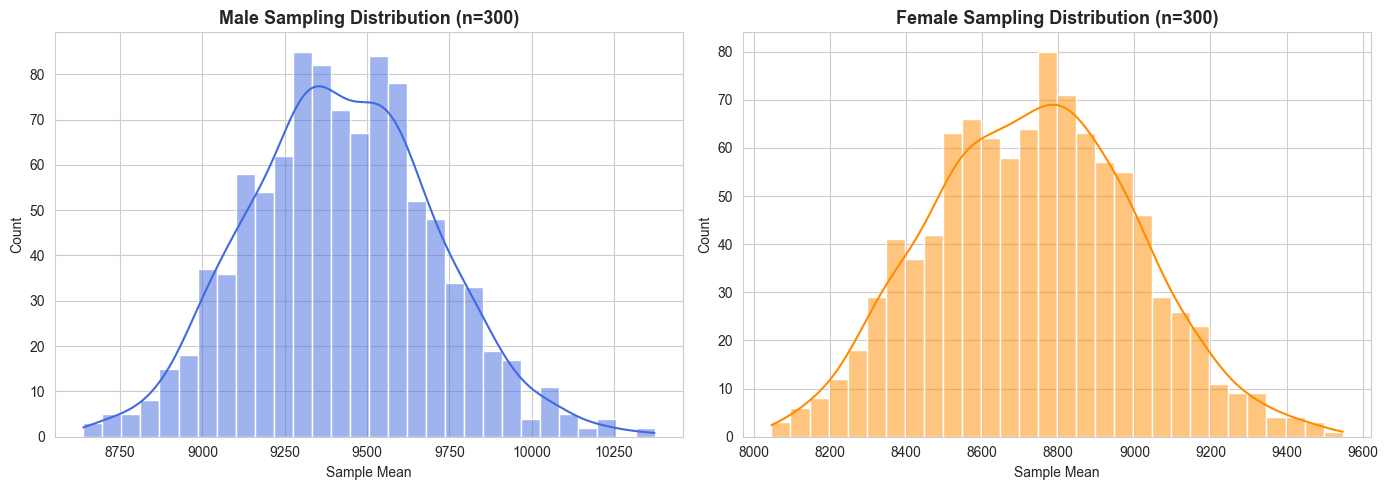


CLT ANALYSIS FOR SAMPLE SIZE = 3000

Male CI   : (np.float64(9247.844142662634), np.float64(9604.997253337366))
Female CI : (np.float64(8572.601708068758), np.float64(8902.630537931242))

Male CI Width   : 357.15
Female CI Width : 330.03

Confidence Intervals DO NOT overlap

Inference:
Male and female spending behavior differs
significantly for this sample size.



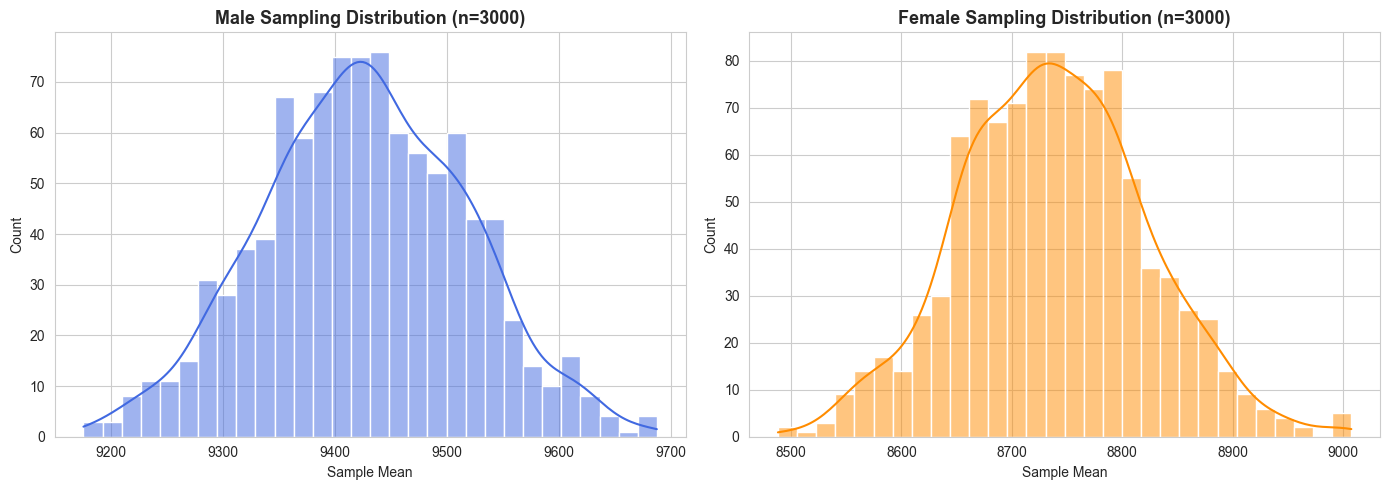


CLT ANALYSIS FOR SAMPLE SIZE = 30000

Male CI   : (np.float64(9369.684539590198), np.float64(9484.504612609799))
Female CI : (np.float64(8683.931634380815), np.float64(8788.89294241919))

Male CI Width   : 114.82
Female CI Width : 104.96

Confidence Intervals DO NOT overlap

Inference:
Male and female spending behavior differs
significantly for this sample size.



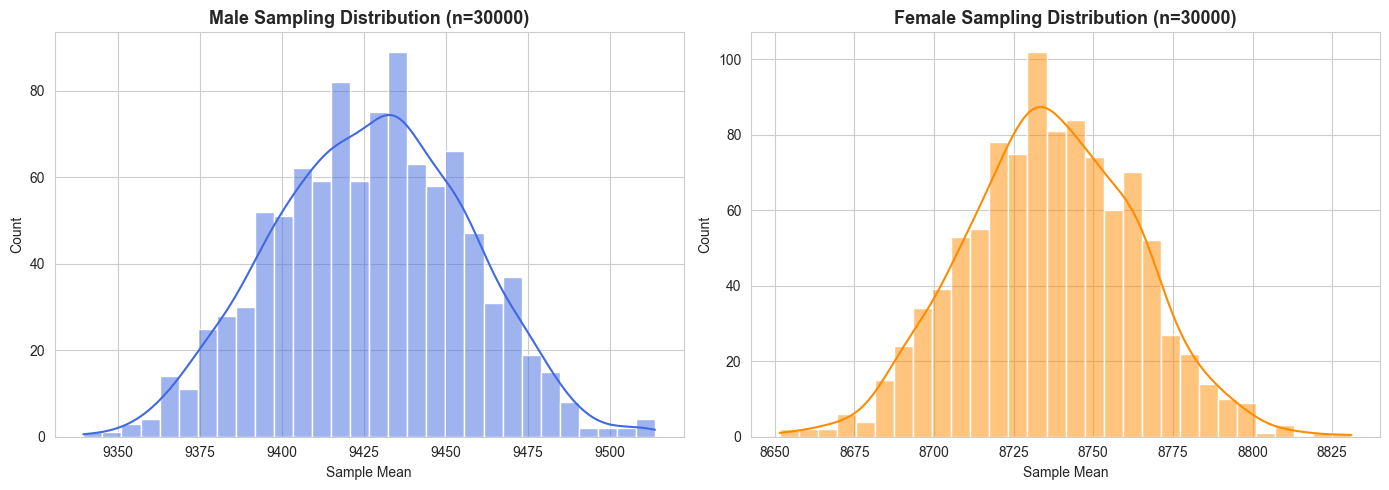


FINAL RESULTS TABLE
   Sample_Size  Male_CI_Lower  Male_CI_Upper  Male_CI_Width  Female_CI_Lower  \
0          300    8866.653336    9978.827351    1112.174015      8207.848969   
1         3000    9247.844143    9604.997253     357.153111      8572.601708   
2        30000    9369.684540    9484.504613     114.820073      8683.931634   

   Female_CI_Upper  Female_CI_Width  
0      9258.943111      1051.094141  
1      8902.630538       330.028830  
2      8788.892942       104.961308  


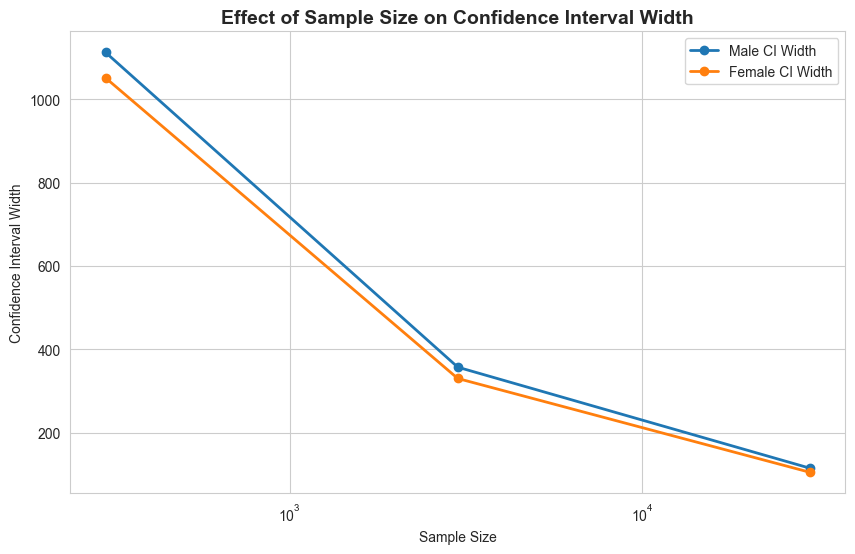

In [70]:



def generate_sample_means(data, sample_size, n_iterations=1000):

    sample_means = [

        data.sample(sample_size, replace=True).mean()

        for _ in range(n_iterations)
    ]

    return sample_means


# ============================================================
# SAMPLE SIZES
# ============================================================

sample_sizes = [300, 3000, 30000]


# ============================================================
# STORE RESULTS
# ============================================================

results = []


# ============================================================
# CLT ANALYSIS LOOP
# ============================================================

for size in sample_sizes:

    # --------------------------------------------------------
    # Generate Sample Means
    # --------------------------------------------------------

    male_sample_means = generate_sample_means(
        male_purchase,
        size
    )

    female_sample_means = generate_sample_means(
        female_purchase,
        size
    )


    # --------------------------------------------------------
    # Compute Mean & CI
    # --------------------------------------------------------

    male_mean = np.mean(male_sample_means)

    male_std_error = np.std(male_sample_means)

    male_ci = norm.interval(
        0.95,
        loc=male_mean,
        scale=male_std_error
    )


    female_mean = np.mean(female_sample_means)

    female_std_error = np.std(female_sample_means)

    female_ci = norm.interval(
        0.95,
        loc=female_mean,
        scale=female_std_error
    )


    # --------------------------------------------------------
    # CI Width
    # --------------------------------------------------------

    male_width = male_ci[1] - male_ci[0]

    female_width = female_ci[1] - female_ci[0]


    # --------------------------------------------------------
    # Save Results
    # --------------------------------------------------------

    results.append({

        'Sample_Size': size,

        'Male_CI_Lower': male_ci[0],
        'Male_CI_Upper': male_ci[1],
        'Male_CI_Width': male_width,

        'Female_CI_Lower': female_ci[0],
        'Female_CI_Upper': female_ci[1],
        'Female_CI_Width': female_width

    })


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print("\n" + "="*70)
    print(f"CLT ANALYSIS FOR SAMPLE SIZE = {size}")
    print("="*70)

    print(f"\nMale CI   : {male_ci}")
    print(f"Female CI : {female_ci}")

    print(f"\nMale CI Width   : {male_width:.2f}")
    print(f"Female CI Width : {female_width:.2f}")


    # --------------------------------------------------------
    # OVERLAP INTERPRETATION
    # --------------------------------------------------------

    if male_ci[0] > female_ci[1] or female_ci[0] > male_ci[1]:

        print("\nConfidence Intervals DO NOT overlap")

        print("""
Inference:
Male and female spending behavior differs
significantly for this sample size.
""")

    else:

        print("\nConfidence Intervals overlap")

        print("""
Inference:
Male and female spending behavior may be similar.
""")


    # --------------------------------------------------------
    # PLOT DISTRIBUTIONS OF SAMPLE MEANS
    # --------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Male Distribution
    sns.histplot(
        male_sample_means,
        bins=30,
        kde=True,
        ax=axes[0],
        color='royalblue'
    )

    axes[0].set_title(
        f'Male Sampling Distribution (n={size})',
        fontsize=13,
        fontweight='bold'
    )

    axes[0].set_xlabel('Sample Mean')


    # Female Distribution
    sns.histplot(
        female_sample_means,
        bins=30,
        kde=True,
        ax=axes[1],
        color='darkorange'
    )

    axes[1].set_title(
        f'Female Sampling Distribution (n={size})',
        fontsize=13,
        fontweight='bold'
    )

    axes[1].set_xlabel('Sample Mean')

    plt.tight_layout()

    plt.show()


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("FINAL RESULTS TABLE")
print("="*70)

print(results_df)


# ============================================================
# VISUALIZE CI WIDTH REDUCTION
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    results_df['Sample_Size'],
    results_df['Male_CI_Width'],
    marker='o',
    linewidth=2,
    label='Male CI Width'
)

plt.plot(
    results_df['Sample_Size'],
    results_df['Female_CI_Width'],
    marker='o',
    linewidth=2,
    label='Female CI Width'
)

plt.xscale('log')

plt.title(
    'Effect of Sample Size on Confidence Interval Width',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Sample Size')

plt.ylabel('Confidence Interval Width')

plt.legend()

plt.show()

